In [20]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [4]:
p = Path('../../../data/raw/lecture/public-covid-data/')

In [10]:
target_folders = {'rp_im', 'rp_msk'}
df_dict = {}

for folder in p.iterdir():
    if not folder.name in target_folders:
        continue

    df_dict[folder.name] = pd.DataFrame(
        [
            {
                'path': f.as_posix(),
                'filename': f.name,
            } for f in folder.iterdir()
        ]
    )

df = df_dict['rp_im'].merge(df_dict['rp_msk'],
                            on='filename',
                            suffixes=('_im', '_msk'))

In [11]:
df

,path_im,filename,path_msk
0,../../../data/raw/lecture/public-covid-data/rp...,5.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
1,../../../data/raw/lecture/public-covid-data/rp...,9.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
2,../../../data/raw/lecture/public-covid-data/rp...,7.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
3,../../../data/raw/lecture/public-covid-data/rp...,3.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
4,../../../data/raw/lecture/public-covid-data/rp...,1.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
5,../../../data/raw/lecture/public-covid-data/rp...,4.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
6,../../../data/raw/lecture/public-covid-data/rp...,8.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
7,../../../data/raw/lecture/public-covid-data/rp...,6.nii.gz,../../../data/raw/lecture/public-covid-data/rp...
8,../../../data/raw/lecture/public-covid-data/rp...,2.nii.gz,../../../data/raw/lecture/public-covid-data/rp...


In [13]:
path = df['path_im'].iloc[0]
im_nifti = nib.load(path)
data = im_nifti.get_fdata()
data

array([[[-1047.62854004, -1041.65917969, -1035.73071289, ...,
         -1017.82244873, -1023.79187012, -1041.65917969],
        [-1047.62854004, -1047.62854004, -1041.65917969, ...,
         -1029.76123047, -1023.79187012, -1041.65917969],
        [-1041.65917969, -1047.62854004, -1047.62854004, ...,
         -1035.73071289, -1023.79187012, -1035.73071289],
        ...,
        [-1023.79187012, -1029.76123047, -1023.79187012, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1023.79187012, -1029.76123047, -1023.79187012, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1029.76123047, -1035.73071289, -1029.76123047, ...,
         -1035.73071289, -1041.65917969, -1041.65917969]],

       [[-1035.73071289, -1035.73071289, -1029.76123047, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1035.73071289, -1041.65917969, -1041.65917969, ...,
         -1041.65917969, -1035.73071289, -1035.73071289],
        [-1041.65917969, 

In [27]:
im_nifti.get_fdata()

array([[[-1047.62854004, -1041.65917969, -1035.73071289, ...,
         -1017.82244873, -1023.79187012, -1041.65917969],
        [-1047.62854004, -1047.62854004, -1041.65917969, ...,
         -1029.76123047, -1023.79187012, -1041.65917969],
        [-1041.65917969, -1047.62854004, -1047.62854004, ...,
         -1035.73071289, -1023.79187012, -1035.73071289],
        ...,
        [-1023.79187012, -1029.76123047, -1023.79187012, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1023.79187012, -1029.76123047, -1023.79187012, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1029.76123047, -1035.73071289, -1029.76123047, ...,
         -1035.73071289, -1041.65917969, -1041.65917969]],

       [[-1035.73071289, -1035.73071289, -1029.76123047, ...,
         -1035.73071289, -1035.73071289, -1035.73071289],
        [-1035.73071289, -1041.65917969, -1041.65917969, ...,
         -1041.65917969, -1035.73071289, -1035.73071289],
        [-1041.65917969, 

In [14]:
data.shape

(630, 630, 66)

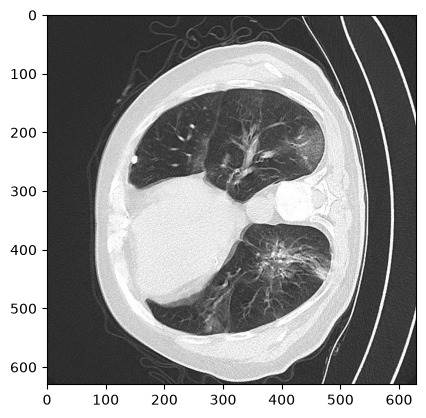

In [19]:
plt.imshow(data[:, :, 20], cmap='gray')

In [22]:
data_t = np.transpose(data)
data_t.shape

(66, 630, 630)

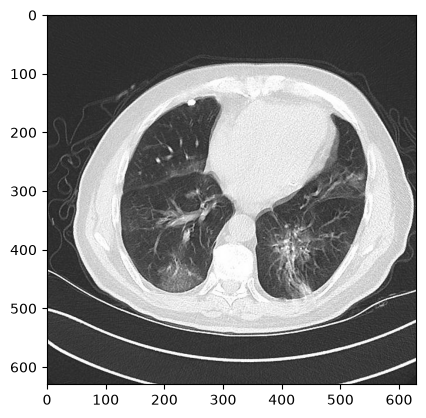

In [24]:
plt.imshow(data_t[20, :, :], cmap='gray')

In [28]:
def load_nifti(path):
    im_nifti = nib.load(path)
    data = im_nifti.get_fdata()
    data = np.transpose(data)

    return data

In [29]:
data = load_nifti(path)

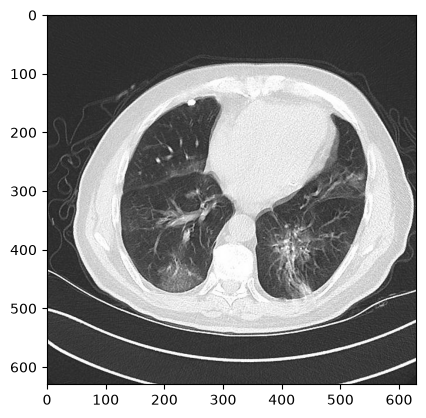

In [31]:
plt.imshow(data[20], cmap='gray')